# Hola

En esta notebook se busca maximizar la varianza entre las imagenes cortadas en cuadrantes.

Se entrena una red para cada cuadrante y al final se usa un clasificador RBF con las probabilidades de las 4 redes como entradas.


# Loading the DataSet

In [1]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch, numpy as np

In [2]:
painter_to_genre = {
    "Joan": "Surrealismo",
    "Salvador": "Surrealismo",
    "Rene": "Surrealismo",
    "Pablo": "Cubismo",
    "Jackson": "Expresionismo abstracto",
    "Rembrandt": "Barroco",
    "Caravaggio": "Barroco",
    "Camille": "Impresionismo",
    "Alfred": "Impresionismo",
    "Claude": "Impresionismo",
    "Vincent": "Impresionismo",  
}

genre_to_label = {
    "Surrealismo": 0,
    "Cubismo": 1,
    "Expresionismo abstracto": 2,
    "Barroco": 3,
    "Impresionismo": 4,
}

In [ ]:
from pathlib import Path
import pandas as pd

root = Path("08 Clasificacion de Movimientos Artisticos/data")

# recoge todos los .jpg (ajusta extensiones si hay .png, etc.)
paths = sorted(root.glob("*.jpg"))

rows = []
for p in paths:
    stem = p.stem  # 'Joan_Miro_001'
    # ejemplo simple: pintor = todo menos la parte final si es número
    painter = stem.split("_")[0]
    genre = painter_to_genre[painter]
    label = genre_to_label[genre]

    rows.append({
        "path": str(p),
        "painter": painter,
        "genre": genre,
        "label": label,
    })

df = pd.DataFrame(rows)

In [4]:
print(df['genre'].value_counts())
df.head()

genre
Impresionismo              75
Surrealismo                50
Barroco                    30
Cubismo                    30
Expresionismo abstracto    15
Name: count, dtype: int64


,path,painter,genre,label
0,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
1,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
2,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
3,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4
4,08 Clasificacion de Movimientos Artisticos\dat...,Alfred,Impresionismo,4


In [4]:
from torch.utils.data import Dataset
from PIL import Image

class PaintingDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        y = int(row["label"])
        if self.transform is not None:
            img = self.transform(img)
        return img, y


# Data Engineering 😜

In [5]:
from torchvision.transforms import functional as TF

class QuadrantCrop:
    """
    quadrant ∈ {"ul", "ur", "ll", "lr"}.
    Crops the corresponding quarter of the image.
    """
    def __init__(self, quadrant: str):
        assert quadrant in {"ul", "ur", "ll", "lr"}
        self.quadrant = quadrant

    def __call__(self, img):
        # img is a PIL.Image
        w, h = img.size  # (width, height)

        crop_w = w // 2
        crop_h = h // 2

        if self.quadrant == "ul":
            left, top = 0, 0
        elif self.quadrant == "ur":
            left, top = w - crop_w, 0
        elif self.quadrant == "ll":
            left, top = 0, h - crop_h
        else:  # "lr"
            left, top = w - crop_w, h - crop_h

        # use torchvision.transforms.functional, NOT torch.nn.functional
        return TF.crop(img, top, left, crop_h, crop_w)


## maximize variance

In [6]:
import json
with open('08 Clasificacion de Movimientos Artisticos/info/best_params.json', 'r') as f:
    best_params = json.load(f)

In [7]:
# read mean_ul, std_ul, mean_ur, std_ur, mean_ll, std_ll, mean_lr, std_lr from json
import json
with open('08 Clasificacion de Movimientos Artisticos/info/mean_std.json', 'r') as f:
    mean_std = json.load(f)
    
mean_ul = np.array(mean_std["mean_ul"])
std_ul = np.array(mean_std["std_ul"])
mean_ur = np.array(mean_std["mean_ur"])
std_ur = np.array(mean_std["std_ur"])
mean_ll = np.array(mean_std["mean_ll"])
std_ll = np.array(mean_std["std_ll"])
mean_lr = np.array(mean_std["mean_lr"])
std_lr = np.array(mean_std["std_lr"])

In [8]:
transf_ul = transforms.Compose([
    QuadrantCrop("ul"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['ul']['c'], saturation=best_params['ul']['s'], brightness=best_params['ul']['b'], hue=best_params['ul']['h']),
    transforms.ToTensor(),
    # transforms.Normalize(mean=mean_ul.tolist(), std=std_ul.tolist()),
])

transf_ur = transforms.Compose([
    QuadrantCrop("ur"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['ur']['c'], saturation=best_params['ur']['s'], brightness=best_params['ur']['b'], hue=best_params['ur']['h']),
    transforms.ToTensor(),
    # transforms.Normalize(mean=mean_ur.tolist(), std=std_ur.tolist()),
])

transf_ll = transforms.Compose([
    QuadrantCrop("ll"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['ll']['c'], saturation=best_params['ll']['s'], brightness=best_params['ll']['b'], hue=best_params['ll']['h']),
    transforms.ToTensor(),
    # transforms.Normalize(mean=mean_ll.tolist(), std=std_ll.tolist()),
])

transf_lr = transforms.Compose([
    QuadrantCrop("lr"),
    transforms.Resize((128, 128)),
    transforms.ColorJitter(contrast=best_params['lr']['c'], saturation=best_params['lr']['s'], brightness=best_params['lr']['b'], hue=best_params['lr']['h']),
    transforms.ToTensor(),
    # transforms.Normalize(mean=mean_lr.tolist(), std=std_lr.tolist()),
])


# Transfarmation and split train and validation sets

In [9]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=863)

In [10]:
train_ul = PaintingDataset(train_df, transform=transf_ul)
train_ur = PaintingDataset(train_df, transform=transf_ur)
train_ll = PaintingDataset(train_df, transform=transf_ll)
train_lr = PaintingDataset(train_df, transform=transf_lr)

val_ul = PaintingDataset(val_df, transform=transf_ul)
val_ur = PaintingDataset(val_df, transform=transf_ur)
val_ll = PaintingDataset(val_df, transform=transf_ll)
val_lr = PaintingDataset(val_df, transform=transf_lr)

In [11]:
import torch.utils.data
train_ds = torch.utils.data.ConcatDataset([train_ul, train_ur, train_ll, train_lr])
val_ds = torch.utils.data.ConcatDataset([val_ul, val_ur, val_ll, val_lr])

# Visualización de imágenes con los mejores parámetros encontrados

Label: 4 Impresionismo


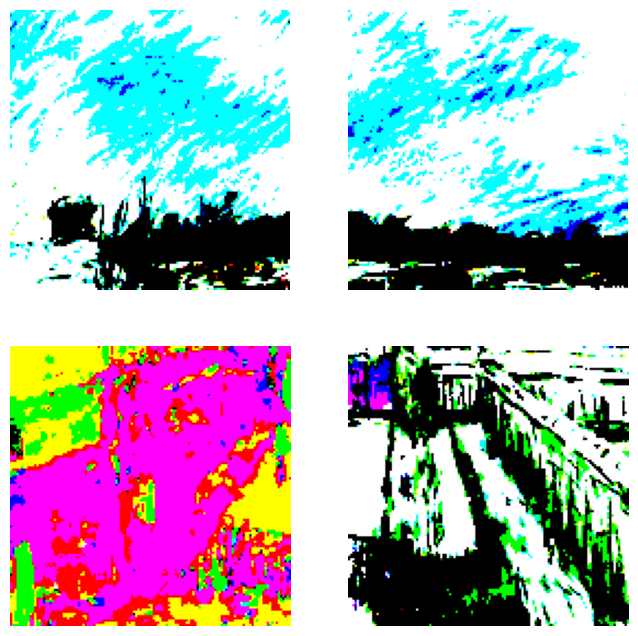

In [13]:
import random
r = random.randint(0, len(train_ul)-1)

img_ul, y = train_ul[r]
img_ur, y = train_ur[r]
img_ll, y = train_ll[r]
img_lr, y = train_lr[r]

print("Label:", y, train_df.iloc[r]["genre"])


import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

axes[0,0].imshow((img_ul).permute(1,2,0).cpu().numpy())
axes[0,0].axis("off")

axes[0,1].imshow((img_ur).permute(1,2,0).cpu().numpy())
axes[0,1].axis("off")

axes[1,0].imshow((img_ll).permute(1,2,0).cpu().numpy())
axes[1,0].axis("off")

axes[1,1].imshow((img_lr).permute(1,2,0).cpu().numpy())
axes[1,1].axis("off")

plt.show()


# ReLU

In [12]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [13]:
import numpy as np
import torch

NUM_CLASSES = len(genre_to_label)

# labels must be integers 0..C-1 (you already have that)
labels_train = train_df["label"].values  # shape (N_train,)

# counts per class, ordered by label index
class_counts = np.bincount(labels_train, minlength=NUM_CLASSES).astype(float)
print("class_counts:", class_counts)

# inverse-frequency weights (rarer classes get higher weight)
class_weights = 1.0 / class_counts
# optional: normalize so average weight ~1
class_weights = class_weights * (NUM_CLASSES / class_weights.sum())
print("class_weights:", class_weights)

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)


class_counts: [180.  72.  59. 117. 247.]
class_weights: [0.56701853 1.41754633 1.72988705 0.8723362  0.41321189]


In [14]:
# Dicts to refer to quadrant datasets by name
quadrant_train_ds = {
    "ul": train_ul,
    "ur": train_ur,
    "ll": train_ll,
    "lr": train_lr,
}
quadrant_val_ds = {
    "ul": val_ul,
    "ur": val_ur,
    "ll": val_ll,
    "lr": val_lr,
}

# Also keep transforms in a dict (for later inference/meta features)
transforms_quadrant = {
    "ul": transf_ul,
    "ur": transf_ur,
    "ll": transf_ll,
    "lr": transf_lr,
}

In [15]:
# ReLU for each quadrant

import torch.nn as nn
import torch.nn.functional as F
import torch.nn.functional as Fnn


NUM_CLASSES = len(genre_to_label)

class SmallCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.flatten = nn.Flatten()
        self.features = nn.Sequential(
            nn.Linear(3 * 128 * 128, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.features(x)
        x = self.classifier(x)
        return x


In [16]:
# Training loop for a single model
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
from torch.optim import Adam
from tqdm import tqdm

def train_one_model(train_loader, val_loader, num_epochs=10, lr=1e-3,
                    class_weights=None):
    model = SmallCNN().to(device)
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_state   = None
    history = {
        "train_loss": [],
        "train_acc":  [],
        "val_loss":   [],
        "val_acc":    [],
    }

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total = 0
        correct = 0

        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)   # <- weighted CE
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = logits.max(1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ---- validation (unweighted metrics) ----
        model.eval()
        val_loss = 0.0
        val_total = 0
        val_correct = 0

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                logits = model(imgs)
                loss = criterion(logits, labels)  # still weighted for loss

                val_loss += loss.item() * imgs.size(0)
                _, preds = logits.max(1)
                val_total   += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"    Epoch {epoch+1:02d} | "
              f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    print("Best val_acc (CNN):", best_val_acc)
    return model, history




In [17]:
# Train one model per quadrant
BATCH_SIZE = 32

models_quadrant   = {}
histories_quadrant = {}

for qname in ["ul", "ur", "ll", "lr"]:
    print(f"\n===== Training quadrant: {qname} =====")

    train_ld_q = DataLoader(
        quadrant_train_ds[qname],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
    )
    val_ld_q = DataLoader(
        quadrant_val_ds[qname],
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    model_q, hist_q = train_one_model(
        train_loader=train_ld_q,
        val_loader=val_ld_q,
        num_epochs=20,
        lr=1e-3,
        class_weights=class_weights_t,   # <- HERE
    )

    models_quadrant[qname] = model_q
    histories_quadrant[qname] = hist_q



===== Training quadrant: ul =====


    Epoch 01 | train_loss=2.0422, train_acc=0.295 | val_loss=2.0497, val_acc=0.280


    Epoch 02 | train_loss=1.4783, train_acc=0.404 | val_loss=1.3625, val_acc=0.427


    Epoch 03 | train_loss=1.2570, train_acc=0.447 | val_loss=1.3998, val_acc=0.520


    Epoch 04 | train_loss=1.1298, train_acc=0.489 | val_loss=1.2661, val_acc=0.613


...

    Epoch 16 | train_loss=0.5251, train_acc=0.785 | val_loss=2.2355, val_acc=0.360


    Epoch 17 | train_loss=0.4419, train_acc=0.812 | val_loss=2.4711, val_acc=0.347


    Epoch 18 | train_loss=0.4317, train_acc=0.812 | val_loss=2.8773, val_acc=0.347


    Epoch 19 | train_loss=0.7247, train_acc=0.677 | val_loss=1.8205, val_acc=0.293


    Epoch 20 | train_loss=0.5024, train_acc=0.800 | val_loss=2.2967, val_acc=0.333
Best val_acc (CNN): 0.4666666666666667


In [26]:
# Build meta-dataset: stacked probabilities from the 4 models
import numpy as np

def build_meta_dataset(df_subset, models_quadrant, transforms_quadrant,
                       batch_size=32):
    quadrant_names = list(models_quadrant.keys())

    # create one dataset / loader per quadrant on this subset
    datasets_q = {
        q: PaintingDataset(df_subset, transform=transforms_quadrant[q])
        for q in quadrant_names
    }
    loaders_q = {
        q: DataLoader(
            datasets_q[q],
            batch_size=batch_size,
            shuffle=False,    # must preserve order
            num_workers=0,
            pin_memory=True,
        )
        for q in quadrant_names
    }

    probs_q = {q: [] for q in quadrant_names}
    labels_all = []

    with torch.no_grad():
        for qi, q in enumerate(quadrant_names):
            model_q = models_quadrant[q].to(device)
            model_q.eval()

            first_q = (qi == 0)

            for imgs, labels in loaders_q[q]:
                imgs = imgs.to(device, non_blocking=True)
                logits = model_q(imgs)                # (B, C)
                probs = torch.softmax(logits, dim=1)  # (B, C)

                probs_q[q].append(probs.cpu())
                if first_q:
                    labels_all.append(labels.clone())

    probs_q_cat = [torch.cat(probs_q[q], dim=0) for q in quadrant_names]  # each (N,C)
    X_meta = torch.cat(probs_q_cat, dim=1).numpy()  # (N, Q*C)
    y_meta = torch.cat(labels_all, dim=0).numpy()   # (N,)

    return X_meta, y_meta

X_train_meta, y_train_meta = build_meta_dataset(
    train_df, models_quadrant, transforms_quadrant, batch_size=BATCH_SIZE
)
X_val_meta,   y_val_meta   = build_meta_dataset(
    val_df, models_quadrant, transforms_quadrant, batch_size=BATCH_SIZE
)

print("X_train_meta shape:", X_train_meta.shape)  # (N_train, 4 * NUM_CLASSES)
print("X_val_meta   shape:", X_val_meta.shape)


X_train_meta shape: (675, 20)
X_val_meta   shape: (75, 20)


# Meta RBF

In [27]:
# RBF meta-classifier on top of stacked probabilities
from sklearn.cluster import KMeans

def init_rbf_centers(X_train_meta, n_centers=20, random_state=42):
    kmeans = KMeans(
        n_clusters=n_centers,
        random_state=random_state,
        n_init="auto"
    )
    kmeans.fit(X_train_meta)
    return kmeans.cluster_centers_

class RBFMeta(nn.Module):
    def __init__(self, in_dim, num_classes, centers, gamma=None, train_gamma=False):
        super().__init__()
        centers = torch.tensor(centers, dtype=torch.float32)
        self.register_buffer("centers", centers)  # (K, D)
        self.K, self.in_dim = centers.shape

        if gamma is None:
            with torch.no_grad():
                c = centers
                dist2 = torch.cdist(c, c, p=2.0) ** 2  # (K,K)
                median_dist2 = torch.median(dist2)
                gamma_val = 1.0 / (2.0 * median_dist2.clamp(min=1e-6))
        else:
            gamma_val = float(gamma)

        if train_gamma:
            self.gamma = nn.Parameter(torch.tensor(gamma_val))
        else:
            self.register_buffer("gamma", torch.tensor(gamma_val))

        self.linear = nn.Linear(self.K, num_classes)

    def forward(self, x):
        # x: (N, D)
        x_expanded = x.unsqueeze(1)           # N x 1 x D
        c_expanded = self.centers.unsqueeze(0)  # 1 x K x D
        dist2 = torch.sum((x_expanded - c_expanded) ** 2, dim=2)  # N x K
        phi = torch.exp(-self.gamma * dist2)  # N x K
        logits = self.linear(phi)             # N x num_classes
        return logits

def train_rbf_meta(X_train, y_train, X_val, y_val,
                   n_centers=20, num_epochs=100, lr=1e-3,
                   class_weights=None):

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
    X_val_t   = torch.tensor(X_val,   dtype=torch.float32).to(device)
    y_val_t   = torch.tensor(y_val,   dtype=torch.long).to(device)

    centers = init_rbf_centers(X_train, n_centers=n_centers)
    model = RBFMeta(
        in_dim=X_train.shape[1],
        num_classes=NUM_CLASSES,
        centers=centers,
        gamma=None,
        train_gamma=False,
    ).to(device)

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train_t)
        loss = criterion(logits, y_train_t)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            _, pred_train = logits.max(1)
            train_acc = (pred_train == y_train_t).float().mean().item()

            model.eval()
            logits_val = model(X_val_t)
            val_loss = criterion(logits_val, y_val_t).item()
            _, pred_val = logits_val.max(1)
            val_acc = (pred_val == y_val_t).float().mean().item()

        print(f"[RBF] Epoch {epoch+1:03d} | "
              f"train_loss={loss.item():.4f}, train_acc={train_acc:.3f} | "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)
    print("Best val_acc (RBF meta):", best_val_acc)

    return model


In [28]:
def predict_weighted_probs(img, models_quadrant, transforms_quadrant, alpha):
    # alpha: dict {"ul": α_ul, ...}
    probs_total = None

    with torch.no_grad():
        for q, model_q in models_quadrant.items():
            x_q = transforms_quadrant[q](img).unsqueeze(0).to(device)
            logits_q = model_q.to(device)(x_q)
            p_q = torch.softmax(logits_q, dim=1).cpu()  # 1×C

            w = alpha[q]
            if probs_total is None:
                probs_total = w * p_q
            else:
                probs_total += w * p_q

    probs_total = probs_total / probs_total.sum(dim=1, keepdim=True)
    pred = probs_total.argmax(dim=1).item()
    return pred, probs_total.numpy()[0]

# get best val accuracy per quadrant
acc_quadrant = {}
for q in ["ul", "ur", "ll", "lr"]:
    hist = histories_quadrant[q]
    best_val = max(hist["val_acc"])
    acc_quadrant[q] = best_val

print(acc_quadrant)

# e.g. α_q = best_val_acc / sum(best_val_acc)
sum_acc = sum(acc_quadrant.values())
alpha = {q: acc_quadrant[q] / sum_acc for q in acc_quadrant}
print("alpha (weights):", alpha)

def build_meta_dataset_weighted(df_subset, models_quadrant, transforms_quadrant,
                                alpha, batch_size=32):
    quadrant_names = list(models_quadrant.keys())

    datasets_q = {
        q: PaintingDataset(df_subset, transform=transforms_quadrant[q])
        for q in quadrant_names
    }
    loaders_q = {
        q: DataLoader(
            datasets_q[q],
            batch_size=batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True,
        )
        for q in quadrant_names
    }

    probs_q = {q: [] for q in quadrant_names}
    labels_all = []

    with torch.no_grad():
        for qi, q in enumerate(quadrant_names):
            model_q = models_quadrant[q].to(device)
            model_q.eval()
            first_q = (qi == 0)

            for imgs, labels in loaders_q[q]:
                imgs = imgs.to(device, non_blocking=True)
                logits = model_q(imgs)
                probs = torch.softmax(logits, dim=1).cpu()  # (B, C)

                # multiply by quadrant weight α_q
                probs_q[q].append(alpha[q] * probs)

                if first_q:
                    labels_all.append(labels.clone())

    probs_q_cat = [torch.cat(probs_q[q], dim=0) for q in quadrant_names]  # each (N, C)
    X_meta = torch.cat(probs_q_cat, dim=1).numpy()  # (N, Q*C)
    y_meta = torch.cat(labels_all, dim=0).numpy()

    return X_meta, y_meta

X_train_meta, y_train_meta = build_meta_dataset_weighted(
    train_df, models_quadrant, transforms_quadrant, alpha, batch_size=BATCH_SIZE
)
X_val_meta,   y_val_meta   = build_meta_dataset_weighted(
    val_df,   models_quadrant, transforms_quadrant, alpha, batch_size=BATCH_SIZE
)

# then train RBF meta as before
rbf_meta_model = train_rbf_meta(
    X_train_meta, y_train_meta,
    X_val_meta,   y_val_meta,
    n_centers=20,
    num_epochs=1000,
    lr=1e-3,
    class_weights=class_weights_t,  # if you are using imbalance correction
)

{'ul': 0.6133333333333333, 'ur': 0.48, 'll': 0.44, 'lr': 0.4666666666666667}
alpha (weights): {'ul': 0.30666666666666664, 'ur': 0.24, 'll': 0.22, 'lr': 0.23333333333333334}


c:\Users\herie\miniconda3\envs\dl\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\herie\AppData\Local\Temp\ipykernel_21212\3513866009.py:32: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("gamma", torch.tensor(gamma_val))


[RBF] Epoch 001 | train_loss=1.6321, train_acc=0.173 | val_loss=1.6546, val_acc=0.173
[RBF] Epoch 002 | train_loss=1.6277, train_acc=0.173 | val_loss=1.6511, val_acc=0.173
[RBF] Epoch 003 | train_loss=1.6233, train_acc=0.173 | val_loss=1.6477, val_acc=0.173
[RBF] Epoch 004 | train_loss=1.6191, train_acc=0.173 | val_loss=1.6446, val_acc=0.173
[RBF] Epoch 005 | train_loss=1.6151, train_acc=0.173 | val_loss=1.6417, val_acc=0.173
[RBF] Epoch 006 | train_loss=1.6111, train_acc=0.173 | val_loss=1.6390, val_acc=0.173
[RBF] Epoch 007 | train_loss=1.6072, train_acc=0.173 | val_loss=1.6364, val_acc=0.173
[RBF] Epoch 008 | train_loss=1.6034, train_acc=0.173 | val_loss=1.6340, val_acc=0.173
[RBF] Epoch 009 | train_loss=1.5997, train_acc=0.173 | val_loss=1.6318, val_acc=0.173
[RBF] Epoch 010 | train_loss=1.5960, train_acc=0.173 | val_loss=1.6296, val_acc=0.173
[RBF] Epoch 011 | train_loss=1.5925, train_acc=0.173 | val_loss=1.6276, val_acc=0.173
[RBF] Epoch 012 | train_loss=1.5890, train_acc=0.173 |

In [29]:
# ------------------------------------------------------------------
# 7) Inference: full pipeline for a new image
# ------------------------------------------------------------------
from PIL import Image

inv_genre = {v: k for k, v in genre_to_label.items()}

def predict_full_pipeline(img_path, models_quadrant, transforms_quadrant, rbf_meta_model):
    img = Image.open(img_path).convert("RGB")
    quadrant_names = list(models_quadrant.keys())
    probs_all = []

    with torch.no_grad():
        for q in quadrant_names:
            x_q = transforms_quadrant[q](img)   # C x H x W
            x_q = x_q.unsqueeze(0).to(device)   # 1 x C x H x W

            model_q = models_quadrant[q].to(device)
            model_q.eval()
            logits_q = model_q(x_q)
            probs_q = torch.softmax(logits_q, dim=1)  # 1 x C
            probs_all.append(probs_q.cpu())

        feat = torch.cat(probs_all, dim=1).to(device)  # 1 x (4*C)
        rbf_meta_model.eval()
        logits_meta = rbf_meta_model(feat)
        probs_meta = torch.softmax(logits_meta, dim=1)  # 1 x C
        pred_idx = torch.argmax(probs_meta, dim=1).item()

    return pred_idx, probs_meta.cpu().numpy()[0]

# Visualización del modelo

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from scripts import style
style.mpl_apply()

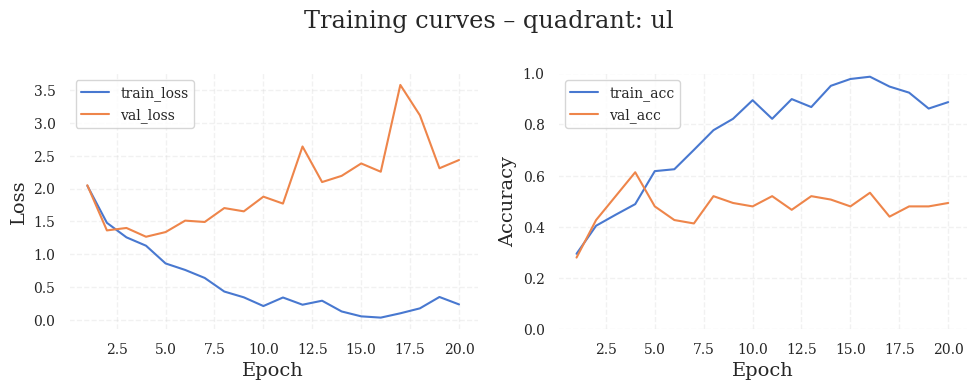

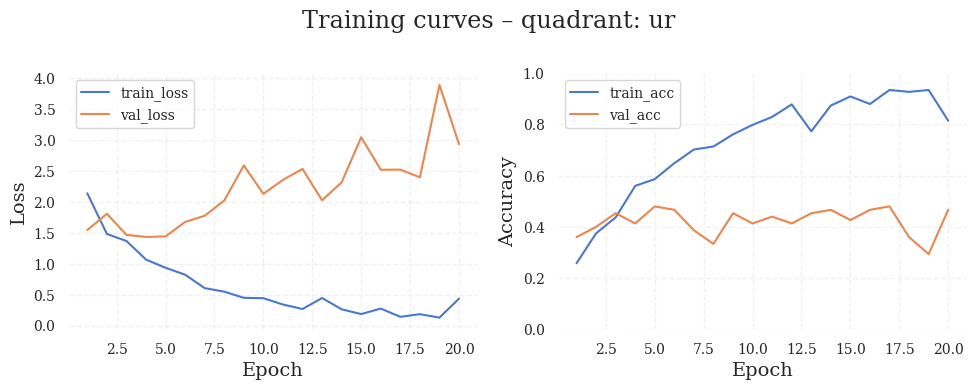

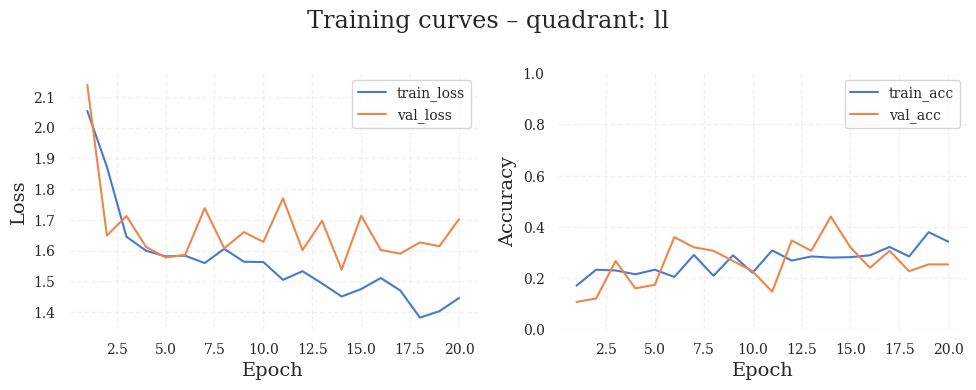

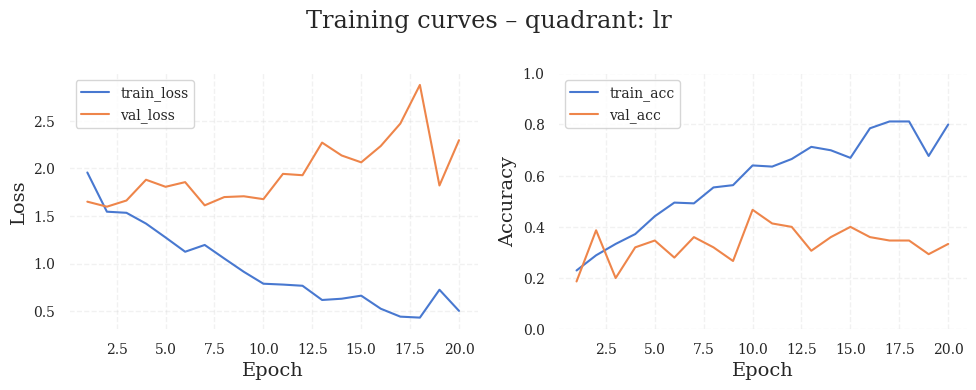

In [23]:
import matplotlib.pyplot as plt

quadrant_names = ["ul", "ur", "ll", "lr"]

for q in quadrant_names:
    hist = histories_quadrant[q]
    epochs = range(1, len(hist["train_loss"]) + 1)

    plt.figure(figsize=(10, 4))
    plt.suptitle(f"Training curves – quadrant: {q}")

    # --- Loss ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["train_loss"], label="train_loss")
    plt.plot(epochs, hist["val_loss"],   label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Accuracy ---
    if "train_acc" in hist:
        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist["train_acc"], label="train_acc")
        plt.plot(epochs, hist["val_acc"],   label="val_acc")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.ylim(0.0, 1.0)
        plt.legend()
        plt.grid(True, alpha=0.3)
    else:
        # fallback if you didn't re-train with train_acc stored
        plt.subplot(1, 2, 2)
        plt.plot(epochs, hist["val_acc"], label="val_acc")
        plt.xlabel("Epoch")
        plt.ylabel("Val accuracy")
        plt.ylim(0.0, 1.0)
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


In [24]:
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt

inv_genre = {v: k for k, v in genre_to_label.items()}
quadrant_names = ["ul", "ur", "ll", "lr"]
import matplotlib.pyplot as plt

inv_genre = {v: k for k, v in genre_to_label.items()}
quadrant_names = ["ul", "ur", "ll", "lr"]

def show_quadrant_probs(img_path, models_quadrant, transforms_quadrant):
    img = Image.open(img_path).convert("RGB")

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    fig.suptitle(f"Quadrant Analysis for {img_path.split('/')[-1]}")

    for i, q in enumerate(quadrant_names):
        # apply transform for this quadrant (includes crop + resize + normalize)
        x_q = transforms_quadrant[q](img)        # C x H x W
        x_vis = x_q.clone()

        # for visualization: un-normalize using that quadrant's mean/std if you want
        # but simplest: just use raw (might look slightly off colors)
        x_vis = x_vis.permute(1, 2, 0).numpy()
        x_vis = np.clip(x_vis, 0, 1)

        # Image in top row
        axes[0, i].imshow(x_vis)
        axes[0, i].axis("off")
        axes[0, i].set_title(f"Quadrant view: {q}")

        # model prediction
        model_q = models_quadrant[q].to(device)
        model_q.eval()

        with torch.no_grad():
            x_batch = x_q.unsqueeze(0).to(device)
            logits = model_q(x_batch)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]  # shape (C,)

        # Bar plot in bottom row
        axes[1, i].bar(range(len(probs)), probs)
        axes[1, i].set_xticks(range(len(probs)))
        axes[1, i].set_xticklabels([inv_genre[j] for j in range(len(probs))], rotation=45, ha="right")
        axes[1, i].set_ylim(0, 1)
        axes[1, i].set_title(f"Probabilities for quadrant {q}")

    plt.tight_layout()
    plt.show()


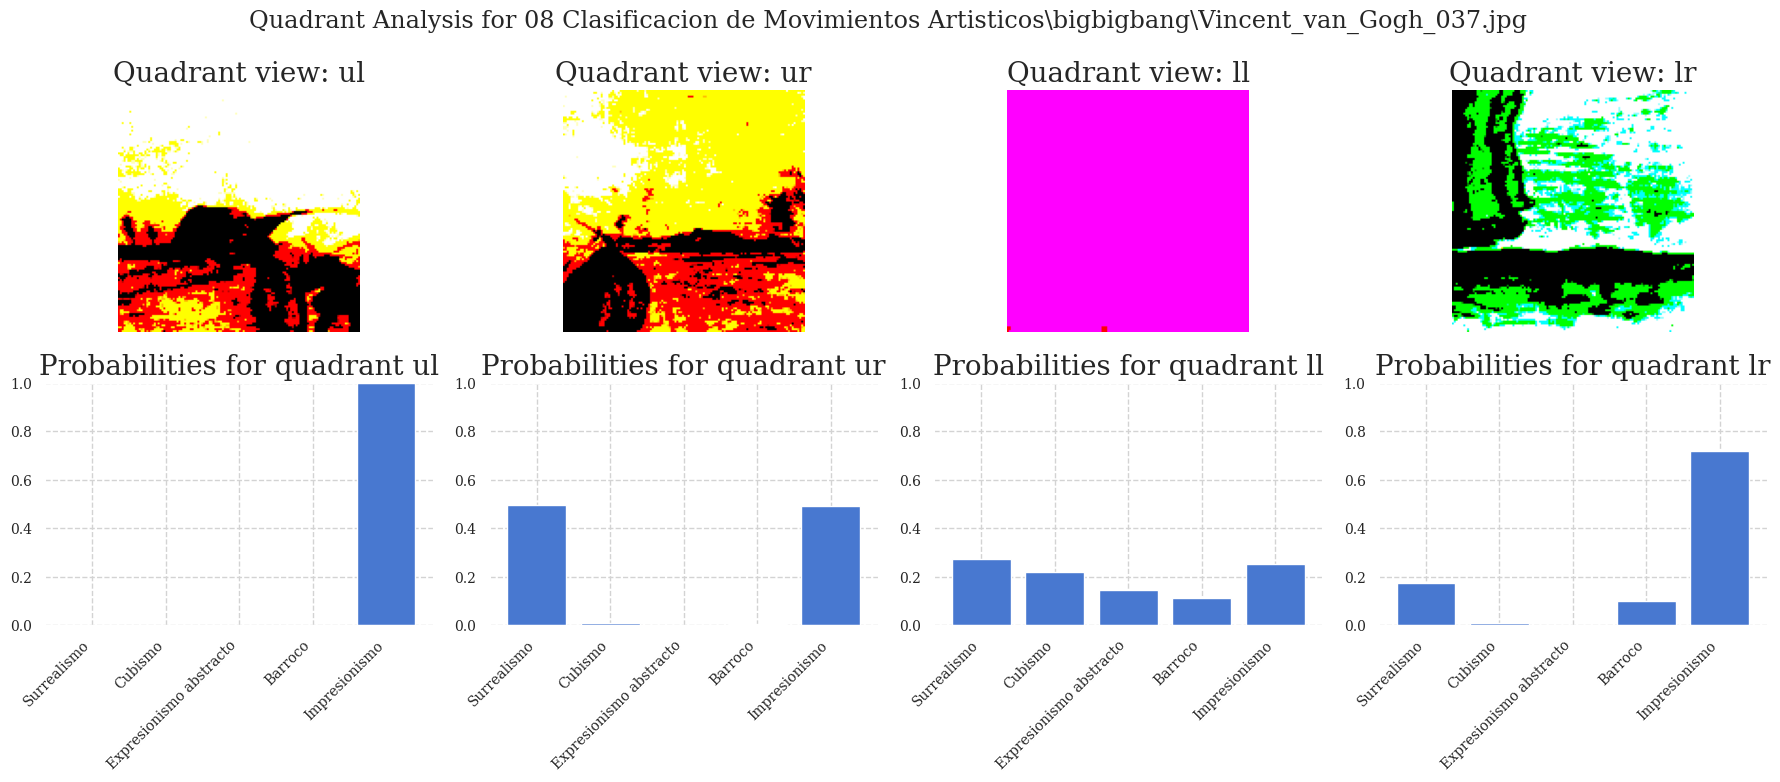

In [30]:
import random   
test_img = random.choice(df['path'].tolist())
show_quadrant_probs(test_img, models_quadrant, transforms_quadrant)

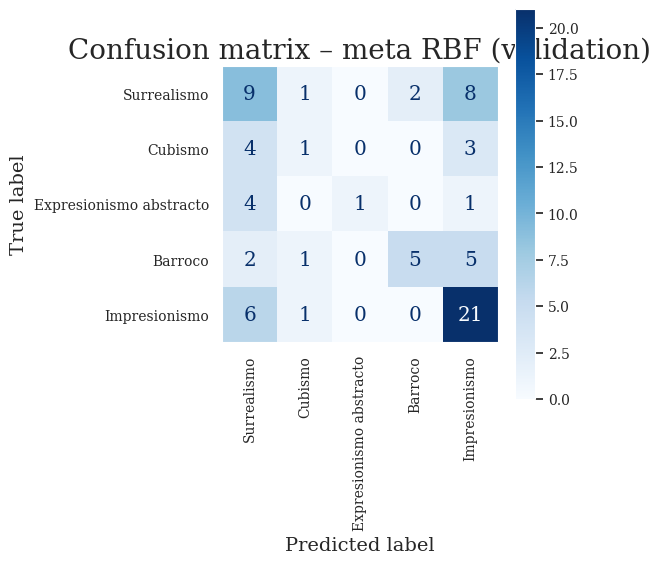

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) meta predictions on validation
rbf_meta_model.eval()
X_val_t = torch.tensor(X_val_meta, dtype=torch.float32).to(device)

with torch.no_grad():
    logits_val = rbf_meta_model(X_val_t)
    probs_val  = torch.softmax(logits_val, dim=1)
    y_pred_val = probs_val.argmax(dim=1).cpu().numpy()

# 2) confusion matrix
cm = confusion_matrix(y_val_meta, y_pred_val)
class_names = [inv_genre[i] for i in range(len(genre_to_label))]

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True)
ax.set_title("Confusion matrix – meta RBF (validation)")
plt.tight_layout()
plt.grid(False)
plt.show()


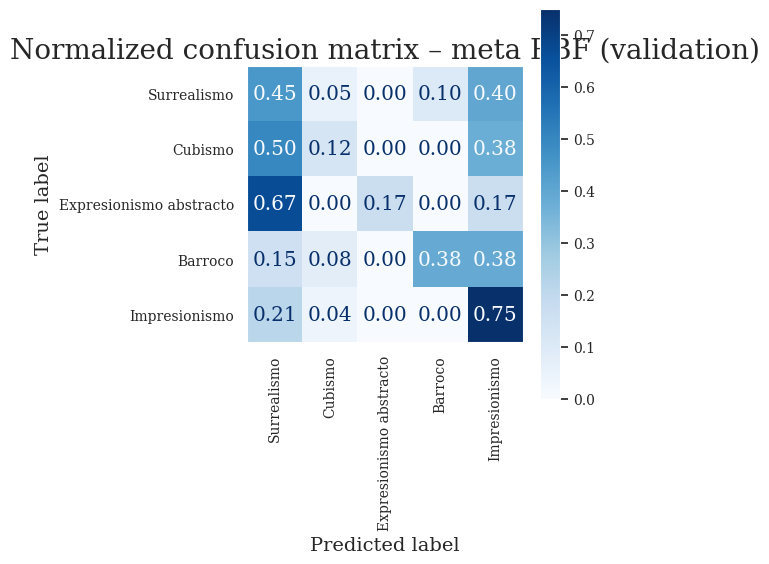

In [32]:
cm_norm = confusion_matrix(y_val_meta, y_pred_val, normalize="true")
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=90, colorbar=True, values_format=".2f")
ax.set_title("Normalized confusion matrix – meta RBF (validation)")
plt.tight_layout()
plt.grid(False)
plt.show()
